In [ ]:
!nvidia-smi


Thu Apr 16 11:12:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
print(f"GPU 名称: {torch.cuda.get_device_name(0)}")
print(f"显存大小: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch 版本: 2.10.0+cu128
CUDA 可用: True
GPU 名称: NVIDIA A100-SXM4-40GB
显存大小: 42.4 GB


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from copy import deepcopy

DEVICE      = torch.device("cuda")
NUM_CLASSES = 10
BATCH_SIZE  = 256
EPOCHS      = 60
LR          = 0.1
SEEDS       = [42, 123]
NOISE_RATES = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
NOISE_TYPES = ["symmetric", "asymmetric"]

print("配置完成，设备:", DEVICE)

配置完成，设备: cuda


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

trainset_clean = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

testloader = DataLoader(testset, batch_size=512, shuffle=False, num_workers=2)

print(f"训练集大小: {len(trainset_clean)}")
print(f"测试集大小: {len(testset)}")
print("CIFAR-10 类别:", trainset_clean.classes)

训练集大小: 50000
测试集大小: 10000
CIFAR-10 类别: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:

def inject_symmetric_noise(targets, noise_rate, num_classes=10, seed=42):
    np.random.seed(seed)
    targets = np.array(targets, dtype=int)
    n_noisy = int(len(targets) * noise_rate)
    noisy_idx = np.random.choice(len(targets), n_noisy, replace=False)
    for i in noisy_idx:
        choices = [c for c in range(num_classes) if c != targets[i]]
        targets[i] = np.random.choice(choices)
    return targets


def inject_asymmetric_noise(targets, noise_rate, seed=42):
    np.random.seed(seed)
    targets = np.array(targets, dtype=int)
    transition = {9: 1, 2: 0, 3: 5, 5: 3, 4: 7, 7: 4}
    for src, dst in transition.items():
        idx = np.where(targets == src)[0]
        n_flip = int(len(idx) * noise_rate)
        if n_flip == 0:
            continue
        flip_idx = np.random.choice(idx, n_flip, replace=False)
        targets[flip_idx] = dst
    return targets


def make_noisy_loader(noise_type, noise_rate, seed, batch_size=256):
    noisy_targets = np.array(trainset_clean.targets, dtype=int)  # 统一转成 numpy
    if noise_rate > 0:
        if noise_type == "symmetric":
            noisy_targets = inject_symmetric_noise(noisy_targets, noise_rate, seed=seed)
        else:
            noisy_targets = inject_asymmetric_noise(noisy_targets, noise_rate, seed=seed)
    noisy_dataset = deepcopy(trainset_clean)
    noisy_dataset.targets = noisy_targets.tolist()  # 现在一定是 numpy，不会报错
    loader = DataLoader(noisy_dataset, batch_size=batch_size,
                        shuffle=True, num_workers=2, pin_memory=True)
    return loader


original = np.array(trainset_clean.targets)
noisy_sym  = inject_symmetric_noise(original, noise_rate=0.3, seed=42)
noisy_asym = inject_asymmetric_noise(original, noise_rate=0.3, seed=42)

print(f"Symmetric  noise 实际翻转比例: {np.mean(original != noisy_sym):.3f}")
print(f"Asymmetric noise 实际翻转比例: {np.mean(original != noisy_asym):.3f}")

Symmetric  noise 实际翻转比例: 0.300
Asymmetric noise 实际翻转比例: 0.162


In [ ]:
def get_resnet18():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, NUM_CLASSES)
    return model.to(DEVICE)


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            total_loss += loss.item()
            correct += outputs.argmax(1).eq(targets).sum().item()
            total += targets.size(0)
    return correct / total, total_loss / len(loader)


def run_experiment(noise_type, noise_rate, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    loader = make_noisy_loader(noise_type, noise_rate, seed)
    model = get_resnet18()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR,
                          momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = GradScaler()

    history = []
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, loader, optimizer, criterion, scaler)
        test_acc, test_loss = evaluate(model, testloader, criterion)
        scheduler.step()
        history.append({
            "epoch": epoch,
            "train_loss": round(train_loss, 4),
            "test_loss": round(test_loss, 4),
            "test_acc": round(test_acc, 4),
        })
        if epoch % 20 == 0:
            print(f"  epoch {epoch:3d} | train_loss {train_loss:.4f} "
                  f"| test_acc {test_acc:.4f}")

    return history


print("模型和训练函数定义完成")

模型和训练函数定义完成


In [ ]:
all_results = {}
total = len(NOISE_TYPES) * len(NOISE_RATES) * len(SEEDS)
done = 0
start_time = time.time()

for noise_type in NOISE_TYPES:
    for noise_rate in NOISE_RATES:
        for seed in SEEDS:
            done += 1
            print(f"\n[{done}/{total}] noise_type={noise_type} | "
                  f"noise_rate={noise_rate} | seed={seed}")

            history = run_experiment(noise_type, noise_rate, seed)
            key = f"{noise_type}_{noise_rate}_{seed}"
            all_results[key] = history

            elapsed = (time.time() - start_time) / 60
            remaining = elapsed / done * (total - done)
            print(f"  已用时 {elapsed:.1f} 分钟，预计剩余 {remaining:.1f} 分钟")

            with open("/content/all_results.json", "w") as f:
                json.dump(all_results, f)

print("\n✅ 全部实验完成，结果已保存到 /content/all_results.json")


[1/24] noise_type=symmetric | noise_rate=0.0 | seed=42


/tmp/ipykernel_2624/47360109.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_2624/47360109.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_2624/47360109.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  epoch  20 | train_loss 0.5876 | test_acc 0.7550
  epoch  40 | train_loss 0.3279 | test_acc 0.8240
  epoch  60 | train_loss 0.1001 | test_acc 0.8673
  已用时 10.9 分钟，预计剩余 250.9 分钟

[2/24] noise_type=symmetric | noise_rate=0.0 | seed=123
  epoch  20 | train_loss 0.5865 | test_acc 0.7575
  epoch  40 | train_loss 0.3333 | test_acc 0.8320
  epoch  60 | train_loss 0.1018 | test_acc 0.8667
  已用时 21.7 分钟，预计剩余 239.2 分钟

[3/24] noise_type=symmetric | noise_rate=0.1 | seed=42
  epoch  20 | train_loss 1.0308 | test_acc 0.7478
  epoch  40 | train_loss 0.7896 | test_acc 0.8001
  epoch  60 | train_loss 0.4680 | test_acc 0.8230
  已用时 32.6 分钟，预计剩余 228.4 分钟

[4/24] noise_type=symmetric | noise_rate=0.1 | seed=123
  epoch  20 | train_loss 1.0359 | test_acc 0.7319
  epoch  40 | train_loss 0.8006 | test_acc 0.8134
  epoch  60 | train_loss 0.4757 | test_acc 0.8340
  已用时 43.5 分钟，预计剩余 217.3 分钟

[5/24] noise_type=symmetric | noise_rate=0.2 | seed=42
  epoch  20 | train_loss 1.3400 | test_acc 0.7027
  epoch  40 

In [ ]:
from google.colab import files
files.download("/content/all_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with open("/content/all_results.json", "r") as f:
    all_results = json.load(f)

print(f"共加载 {len(all_results)} 条实验记录")
print("示例 key：", list(all_results.keys())[:3])

共加载 24 条实验记录
示例 key： ['symmetric_0.0_42', 'symmetric_0.0_123', 'symmetric_0.1_42']


In [ ]:
with open("/content/all_results.json", "r") as f:
    all_results = json.load(f)

def get_mean_std(noise_type, noise_rate):
    accs = []
    for seed in SEEDS:
        key = f"{noise_type}_{noise_rate}_{seed}"
        history = all_results[key]
        final_acc = history[-1]["test_acc"]
        accs.append(final_acc)
    return np.mean(accs), np.std(accs)

def get_history_mean(noise_type, noise_rate):
    all_epochs = []
    for seed in SEEDS:
        key = f"{noise_type}_{noise_rate}_{seed}"
        history = all_results[key]
        accs = [h["test_acc"] for h in history]
        all_epochs.append(accs)
    return np.mean(all_epochs, axis=0), np.std(all_epochs, axis=0)

summary = {}
for ntype in NOISE_TYPES:
    summary[ntype] = {"rates": [], "means": [], "stds": []}
    for rate in NOISE_RATES:
        mean, std = get_mean_std(ntype, rate)
        summary[ntype]["rates"].append(rate)
        summary[ntype]["means"].append(mean)
        summary[ntype]["stds"].append(std)

clean_acc = np.mean([
    all_results[f"symmetric_0.0_{s}"][-1]["test_acc"] for s in SEEDS
])
collapse_threshold = clean_acc * 0.75

print(f"Clean baseline accuracy: {clean_acc:.4f}")
print(f"Collapse threshold (75%): {collapse_threshold:.4f}")
print("\nSummary loaded successfully")

Clean baseline accuracy: 0.8670
Collapse threshold (75%): 0.6502

Summary loaded successfully


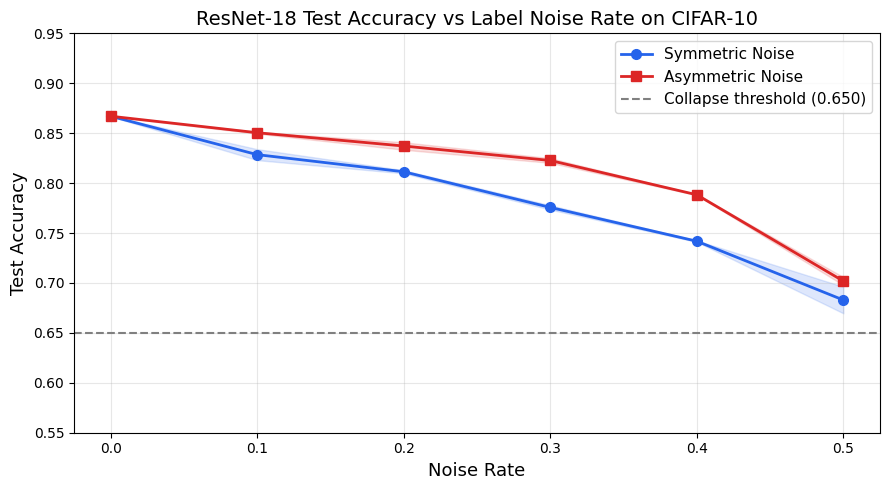

图一保存完成


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = {"symmetric": "#2563EB", "asymmetric": "#DC2626"}
markers = {"symmetric": "o", "asymmetric": "s"}
labels = {"symmetric": "Symmetric Noise", "asymmetric": "Asymmetric Noise"}

for ntype in NOISE_TYPES:
    rates = summary[ntype]["rates"]
    means = summary[ntype]["means"]
    stds  = summary[ntype]["stds"]
    ax.plot(rates, means, color=colors[ntype], marker=markers[ntype],
            linewidth=2, markersize=7, label=labels[ntype])
    ax.fill_between(rates,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    color=colors[ntype], alpha=0.15)

ax.axhline(y=collapse_threshold, color="gray", linestyle="--",
           linewidth=1.5, label=f"Collapse threshold ({collapse_threshold:.3f})")

ax.set_xlabel("Noise Rate", fontsize=13)
ax.set_ylabel("Test Accuracy", fontsize=13)
ax.set_title("ResNet-18 Test Accuracy vs Label Noise Rate on CIFAR-10", fontsize=14)
ax.set_xticks(NOISE_RATES)
ax.set_ylim(0.55, 0.95)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/fig1_main.pdf", dpi=300, bbox_inches="tight")
plt.savefig("/content/fig1_main.png", dpi=300, bbox_inches="tight")
plt.show()
print("图一保存完成")

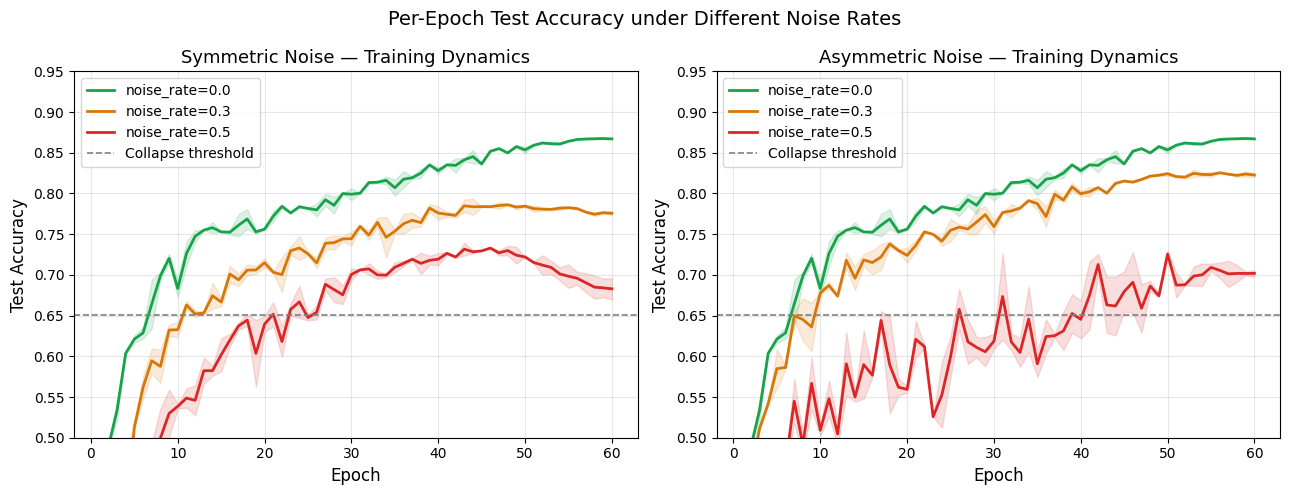

图二保存完成


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

selected_rates = [0.0, 0.3, 0.5]
colors_rate = {0.0: "#16A34A", 0.3: "#D97706", 0.5: "#DC2626"}
epochs_x = list(range(1, EPOCHS + 1))

for idx, ntype in enumerate(NOISE_TYPES):
    ax = axes[idx]
    for rate in selected_rates:
        mean_curve, std_curve = get_history_mean(ntype, rate)
        ax.plot(epochs_x, mean_curve,
                color=colors_rate[rate], linewidth=2,
                label=f"noise_rate={rate}")
        ax.fill_between(epochs_x,
                        mean_curve - std_curve,
                        mean_curve + std_curve,
                        color=colors_rate[rate], alpha=0.15)

    ax.axhline(y=collapse_threshold, color="gray", linestyle="--",
               linewidth=1.2, label=f"Collapse threshold")
    ax.set_title(f"{ntype.capitalize()} Noise — Training Dynamics", fontsize=13)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Test Accuracy", fontsize=12)
    ax.set_ylim(0.50, 0.95)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Per-Epoch Test Accuracy under Different Noise Rates", fontsize=14)
plt.tight_layout()
plt.savefig("/content/fig2_dynamics.pdf", dpi=300, bbox_inches="tight")
plt.savefig("/content/fig2_dynamics.png", dpi=300, bbox_inches="tight")
plt.show()
print("图二保存完成")

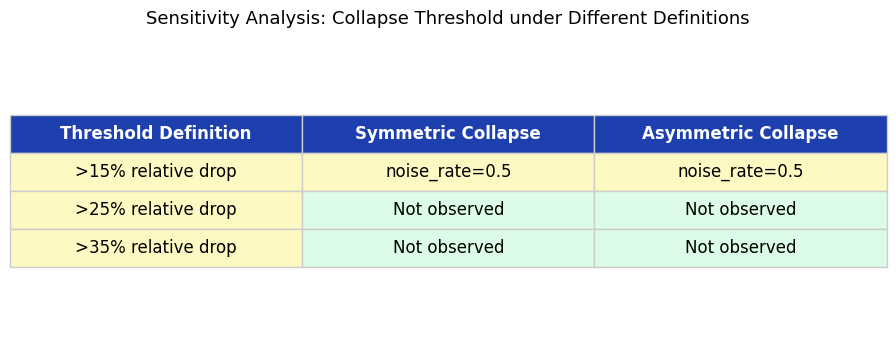

图三保存完成


In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.5))

thresholds_def = [0.15, 0.25, 0.35]
table_data = []
col_labels = ["Threshold Definition", "Symmetric Collapse", "Asymmetric Collapse"]

for t_def in thresholds_def:
    row = [f">{int(t_def*100)}% relative drop"]
    for ntype in NOISE_TYPES:
        found = "Not observed"
        baseline = summary[ntype]["means"][0]
        cutoff = baseline * (1 - t_def)
        for rate, mean in zip(summary[ntype]["rates"], summary[ntype]["means"]):
            if mean < cutoff:
                found = f"noise_rate={rate}"
                break
        row.append(found)
    table_data.append(row)

ax.axis("off")
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.2)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("#CCCCCC")
    if r == 0:
        cell.set_facecolor("#1E40AF")
        cell.set_text_props(color="white", fontweight="bold")
    elif "Not observed" in str(cell.get_text().get_text()):
        cell.set_facecolor("#DCFCE7")
    else:
        cell.set_facecolor("#FEF9C3")

plt.title("Sensitivity Analysis: Collapse Threshold under Different Definitions",
          fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("/content/fig3_sensitivity.pdf", dpi=300, bbox_inches="tight")
plt.savefig("/content/fig3_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
print("图三保存完成")

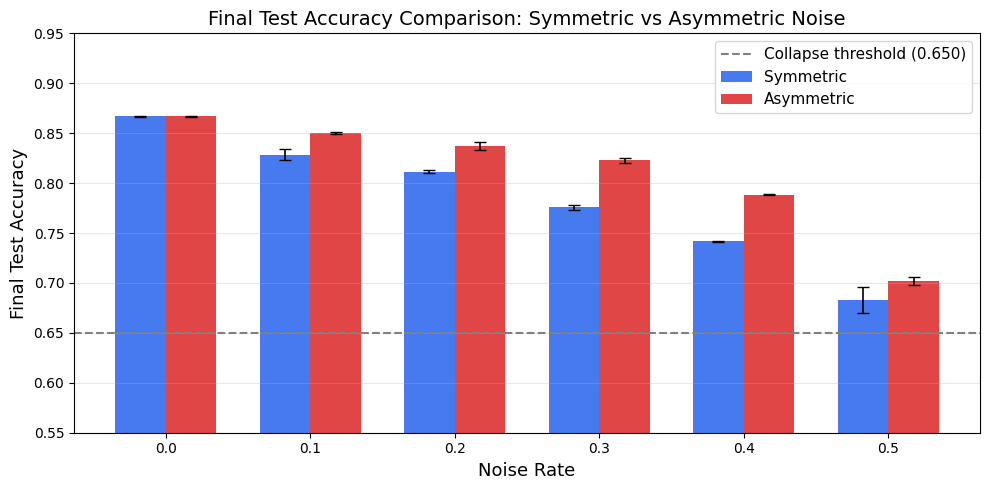

图四保存完成


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(NOISE_RATES))
width = 0.35
colors_bar = {"symmetric": "#2563EB", "asymmetric": "#DC2626"}

for i, ntype in enumerate(NOISE_TYPES):
    means = summary[ntype]["means"]
    stds  = summary[ntype]["stds"]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width,
                  label=ntype.capitalize(),
                  color=colors_bar[ntype],
                  alpha=0.85,
                  yerr=stds, capsize=4, error_kw={"linewidth": 1.2})

ax.axhline(y=collapse_threshold, color="gray", linestyle="--",
           linewidth=1.5, label=f"Collapse threshold ({collapse_threshold:.3f})")

ax.set_xlabel("Noise Rate", fontsize=13)
ax.set_ylabel("Final Test Accuracy", fontsize=13)
ax.set_title("Final Test Accuracy Comparison: Symmetric vs Asymmetric Noise", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in NOISE_RATES])
ax.set_ylim(0.55, 0.95)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/content/fig4_barplot.pdf", dpi=300, bbox_inches="tight")
plt.savefig("/content/fig4_barplot.png", dpi=300, bbox_inches="tight")
plt.show()
print("图四保存完成")

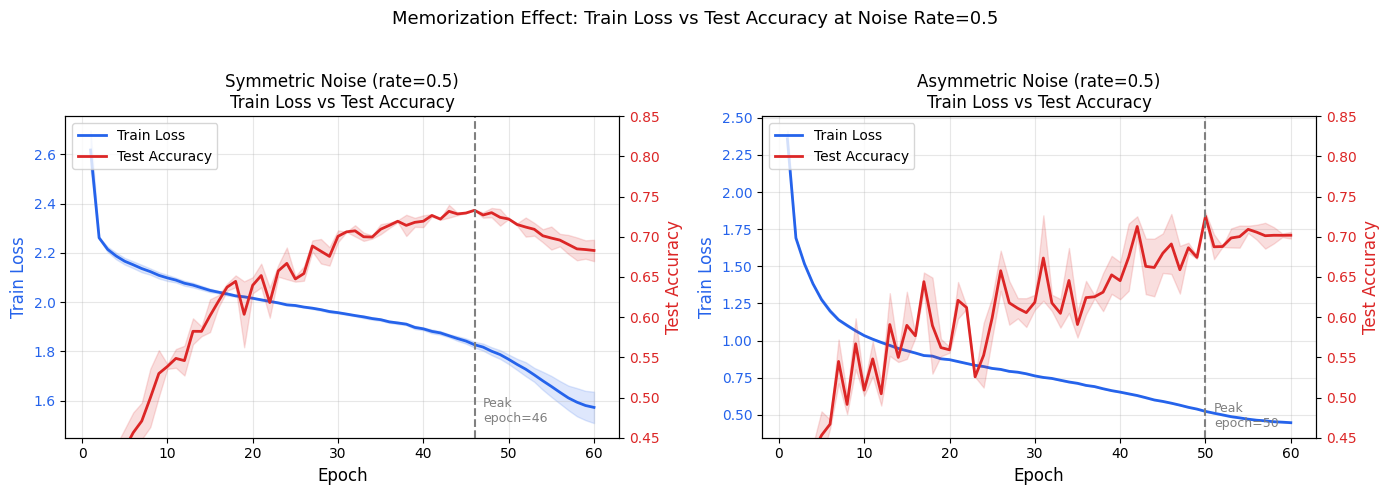

图五保存完成


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_rate = 0.5

for idx, ntype in enumerate(NOISE_TYPES):
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    epochs_x = list(range(1, EPOCHS + 1))

    train_losses, test_accs = [], []
    for seed in SEEDS:
        key = f"{ntype}_{target_rate}_{seed}"
        history = all_results[key]
        train_losses.append([h["train_loss"] for h in history])
        test_accs.append([h["test_acc"] for h in history])

    mean_loss = np.mean(train_losses, axis=0)
    mean_acc  = np.mean(test_accs,   axis=0)
    std_loss  = np.std(train_losses,  axis=0)
    std_acc   = np.std(test_accs,     axis=0)

    peak_epoch = int(np.argmax(mean_acc)) + 1
    peak_acc   = np.max(mean_acc)

    l1, = ax1.plot(epochs_x, mean_loss, color="#2563EB",
                   linewidth=2, label="Train Loss")
    ax1.fill_between(epochs_x,
                     mean_loss - std_loss,
                     mean_loss + std_loss,
                     color="#2563EB", alpha=0.15)
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Train Loss", color="#2563EB", fontsize=12)
    ax1.tick_params(axis="y", labelcolor="#2563EB")

    l2, = ax2.plot(epochs_x, mean_acc, color="#DC2626",
                   linewidth=2, label="Test Accuracy")
    ax2.fill_between(epochs_x,
                     mean_acc - std_acc,
                     mean_acc + std_acc,
                     color="#DC2626", alpha=0.15)
    ax2.set_ylabel("Test Accuracy", color="#DC2626", fontsize=12)
    ax2.tick_params(axis="y", labelcolor="#DC2626")
    ax2.set_ylim(0.45, 0.85)

    ax2.axvline(x=peak_epoch, color="gray", linestyle="--", linewidth=1.5)
    ax1.text(peak_epoch + 1, ax1.get_ylim()[0] + 0.05,
             f"Peak\nepoch={peak_epoch}",
             fontsize=9, color="gray", va="bottom")

    ax1.set_title(f"{ntype.capitalize()} Noise (rate=0.5)\nTrain Loss vs Test Accuracy",
                  fontsize=12)
    ax1.grid(True, alpha=0.3)

    lines = [l1, l2]
    labels_leg = [l.get_label() for l in lines]
    ax1.legend(lines, labels_leg, fontsize=10, loc="upper left")

plt.suptitle("Memorization Effect: Train Loss vs Test Accuracy at Noise Rate=0.5",
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/content/fig5_memorization.pdf", dpi=300, bbox_inches="tight")
plt.savefig("/content/fig5_memorization.png", dpi=300, bbox_inches="tight")
plt.show()
print("图五保存完成")

In [ ]:
from google.colab import files

for fname in ["fig1_main.png", "fig2_dynamics.png",
              "fig3_sensitivity.png", "fig4_barplot.png",
              "fig5_memorization.png"]:
    files.download(f"/content/{fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>